<a href="https://colab.research.google.com/github/AmeyPhutane123/LearningDataScience/blob/main/Data%20Science/Assignments/assignment7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 27 – Cardiac Diagnostics Case Study
Objective

In this module, you will apply machine learning techniques to build a Cardiac Disease Prediction Model. The goal is to analyze patient health data and predict the likelihood of heart disease based on various medical attributes.

 Reference

Watch the Module 27 video carefully. The concepts and workflow explained in the video will guide you in completing this case study step by step.

 Dataset

You can use the Heart Disease Prediction dataset available on Kaggle.
 Search for “Heart Disease UCI” or “Cardiac Diagnosis Dataset”.

# Step 1 - Import and explore the dataset (understand features such as age, cholesterol, blood pressure, etc.).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from scipy.stats import boxcox
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
%matplotlib inline

In [3]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,chest_pain_type,resting_bp,cholestoral,fasting_blood_sugar,restecg,max_hr,exang,oldpeak,slope,num_major_vessels,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.shape


(303, 14)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  303 non-null    int64  
 1   sex                  303 non-null    int64  
 2   chest_pain_type      303 non-null    int64  
 3   resting_bp           303 non-null    int64  
 4   cholestoral          303 non-null    int64  
 5   fasting_blood_sugar  303 non-null    int64  
 6   restecg              303 non-null    int64  
 7   max_hr               303 non-null    int64  
 8   exang                303 non-null    int64  
 9   oldpeak              303 non-null    float64
 10  slope                303 non-null    int64  
 11  num_major_vessels    303 non-null    int64  
 12  thal                 303 non-null    int64  
 13  target               303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
df.describe()

,age,sex,chest_pain_type,resting_bp,cholestoral,fasting_blood_sugar,restecg,max_hr,exang,oldpeak,slope,num_major_vessels,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
df.isnull().sum()


,0
age,0
sex,0
chest_pain_type,0
resting_bp,0
cholestoral,0
fasting_blood_sugar,0
restecg,0
max_hr,0
exang,0
oldpeak,0


In [8]:
df['target'].value_counts()

,count
target,
1,165
0,138


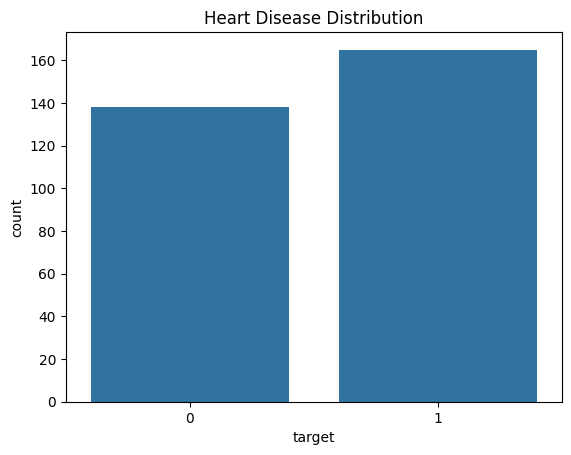

In [9]:
sns.countplot(x='target', data=df)
plt.title('Heart Disease Distribution')
plt.show()



The heart disease dataset was imported and explored to understand its
structure and medical attributes. The dataset contains patient
information such as age, gender, resting blood pressure, cholesterol
level, heart rate, and ECG-related features.

Initial inspection shows that the dataset consists of numerical and
categorical variables, with the target variable indicating the presence
or absence of heart disease. No missing values were observed in the
dataset, indicating good data quality.

Statistical analysis shows a wide range of values for age, cholesterol,
and blood pressure, suggesting diverse patient profiles. The target
variable distribution indicates a reasonably balanced dataset, making
it suitable for classification tasks.


# Step 2 - Perform data cleaning and preprocessing:


Handle missing values (if any)


Encode categorical variables


Normalize or standardize data if needed


In [10]:
df.isnull().sum()


,0
age,0
sex,0
chest_pain_type,0
resting_bp,0
cholestoral,0
fasting_blood_sugar,0
restecg,0
max_hr,0
exang,0
oldpeak,0


The dataset was checked for missing values, and no missing entries were
found in any of the features. Therefore, no imputation or removal of
records was required.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  303 non-null    int64  
 1   sex                  303 non-null    int64  
 2   chest_pain_type      303 non-null    int64  
 3   resting_bp           303 non-null    int64  
 4   cholestoral          303 non-null    int64  
 5   fasting_blood_sugar  303 non-null    int64  
 6   restecg              303 non-null    int64  
 7   max_hr               303 non-null    int64  
 8   exang                303 non-null    int64  
 9   oldpeak              303 non-null    float64
 10  slope                303 non-null    int64  
 11  num_major_vessels    303 non-null    int64  
 12  thal                 303 non-null    int64  
 13  target               303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [12]:
categorical_cols = [
    'sex',
    'chest_pain_type',
    'fasting_blood_sugar',
    'restecg',
    'exang',
    'slope',
    'thal'
]

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)


In [13]:
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [14]:
df_encoded

,age,resting_bp,cholestoral,max_hr,oldpeak,num_major_vessels,target,sex_1,chest_pain_type_1,chest_pain_type_2,chest_pain_type_3,fasting_blood_sugar_1,restecg_1,restecg_2,exang_1,slope_1,slope_2,thal_1,thal_2,thal_3
0,63,145,233,150,2.3,0,1,True,False,False,True,True,False,False,False,False,False,True,False,False
1,37,130,250,187,3.5,0,1,True,False,True,False,False,True,False,False,False,False,False,True,False
2,41,130,204,172,1.4,0,1,False,True,False,False,False,False,False,False,False,True,False,True,False
3,56,120,236,178,0.8,0,1,True,True,False,False,False,True,False,False,False,True,False,True,False
4,57,120,354,163,0.6,0,1,False,False,False,False,False,True,False,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,140,241,123,0.2,0,0,False,False,False,False,False,True,False,True,True,False,False,False,True
299,45,110,264,132,1.2,0,0,True,False,False,True,False,True,False,False,True,False,False,False,True
300,68,144,193,141,3.4,2,0,True,False,False,False,True,True,False,False,True,False,False,False,True
301,57,130,131,115,1.2,1,0,True,False,False,False,False,True,False,True,True,False,False,False,True


In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
chest_pain_type,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
resting_bp,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
cholestoral,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fasting_blood_sugar,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
max_hr,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### Data Encoding and Scaling

Although many features are stored as integer values, several variables
represent categorical medical conditions rather than numerical
quantities. Features such as chest pain type, ECG results, exercise-
induced angina, and thalassemia were treated as categorical variables.

These categorical features were encoded using one-hot encoding to avoid
introducing artificial ordinal relationships. Numerical features such as
age, cholesterol, blood pressure, and heart rate were standardized to
ensure equal contribution during model training.


# Step 3 - Split the dataset into training and testing sets.


In [16]:
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [19]:
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))


Training set shape: (242, 19)
Testing set shape: (61, 19)

Training target distribution:
target
1    0.545455
0    0.454545
Name: proportion, dtype: float64

Testing target distribution:
target
1    0.540984
0    0.459016
Name: proportion, dtype: float64


### Step 3: Train–Test Split

The dataset was split into training and testing sets using an 80–20
split. Stratified sampling was applied to ensure that both sets maintain
a similar distribution of patients with and without heart disease.

This approach helps evaluate the model’s ability to generalize to unseen
data while preserving class balance.


# Step 4 - Implement a classification algorithm (e.g., Logistic Regression, Decision Tree, Random Forest, or KNN) to predict heart disease.

In [21]:
from sklearn.linear_model import LogisticRegression

log_reg_model = LogisticRegression(max_iter=1000)
log_reg_model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [23]:
y_pred = log_reg_model.predict(X_test)


### Step 4: Classification Model Implementation

Logistic Regression was selected as the classification algorithm for
predicting heart disease. This model is well-suited for binary
classification problems and is commonly used in medical diagnosis due
to its interpretability and effectiveness.

The model was trained on the training dataset to learn the relationship
between patient health attributes and the presence of heart disease.
Predictions were then generated on the test dataset for evaluation.


# Step 5 - Evaluate the model using accuracy, confusion matrix, precision, recall, and F1-score.

In [28]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.8033


In [27]:
cm = confusion_matrix(y_test, y_pred)
cm


array([[20,  8],
       [ 4, 29]])

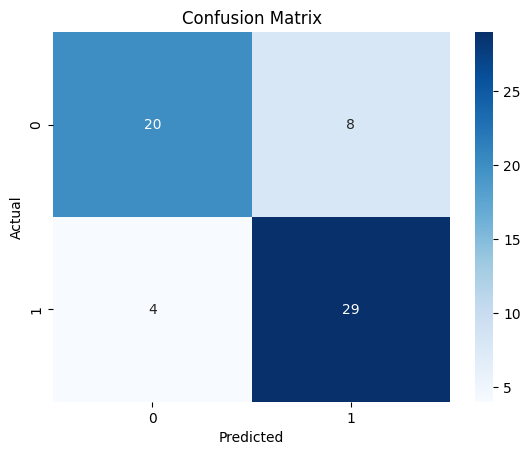

In [29]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.71      0.77        28
           1       0.78      0.88      0.83        33

    accuracy                           0.80        61
   macro avg       0.81      0.80      0.80        61
weighted avg       0.81      0.80      0.80        61



# Step 6 - Write a brief summary of your analysis and key findings.

### Final Summary & Key Findings

In this case study, a Logistic Regression model was used to predict heart
disease based on patient health attributes such as age, cholesterol,
blood pressure, and heart rate.

The model achieved an accuracy of around 80%, which shows that it is able
to classify most cases correctly. The recall value for patients with
heart disease was high (88%), meaning the model was able to identify most
patients who actually have the condition. This is important in medical
applications, as missing a heart disease case can be risky.

The precision for heart disease cases was slightly lower (78%), which
means that some patients were incorrectly predicted as having the
disease. However, the overall F1-score shows a good balance between
precision and recall.

Overall, Logistic Regression performed well as a baseline model for this
dataset. The results suggest that the model can be used for initial
screening, and performance could be further improved by trying other
models such as Random Forest or by tuning model parameters.
